# Setup

In [1]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("amerzishminha/forest-fire-smoke-and-non-fire-image-dataset")

dataset_root = os.path.join(path, 'FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET')

train_dir = os.path.join(dataset_root, 'train')
test_dir = os.path.join(dataset_root, 'test')

if os.path.exists(train_dir):
    print("✅ found 'train' directory")
    print("folders:", os.listdir(train_dir))
else:
    print("❌ failed")

c:\Users\zulay\Desktop\FactoriaF5\Bootcamp\IA\projects\p7_g2_multiclase\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ found 'train' directory
folders: ['fire', 'non fire', 'smoke']


# 00. Data Distribution

--- Train ---
      Class  Count
0      fire  10800
1  non fire  10800
2     smoke  10800

--- Test ---
      Class  Count
0      fire   3500
1  non fire   3500
2     smoke   3500


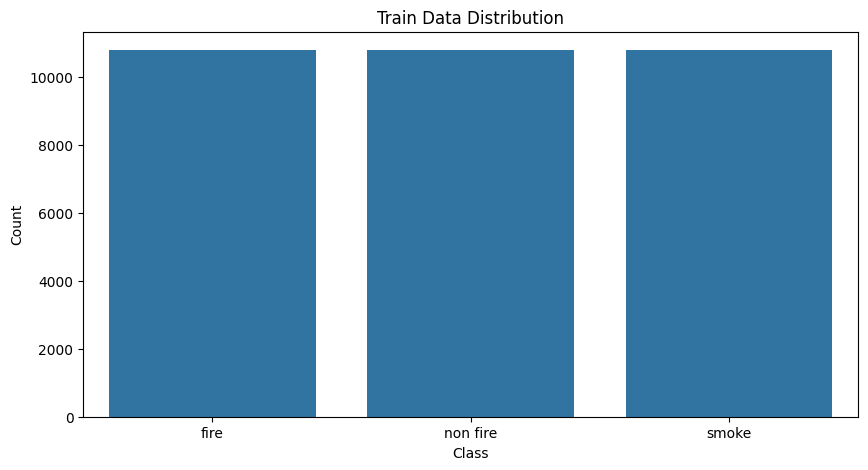

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# count images
def count_images(directory):
    data = []
    for label in os.listdir(directory):
        label_path = os.path.join(directory, label)
        if os.path.isdir(label_path):
            count = len(os.listdir(label_path))
            data.append({'Class': label, 'Count': count})
    return pd.DataFrame(data)

# count Train/Test 
train_counts = count_images(train_dir)
test_counts = count_images(test_dir)

# print
print("--- Train ---")
print(train_counts)
print("\n--- Test ---")
print(test_counts)

# visualization (barplot)
plt.figure(figsize=(10, 5))
sns.barplot(data=train_counts, x='Class', y='Count')
plt.title('Train Data Distribution')
plt.show()

# 01. Visual Grid

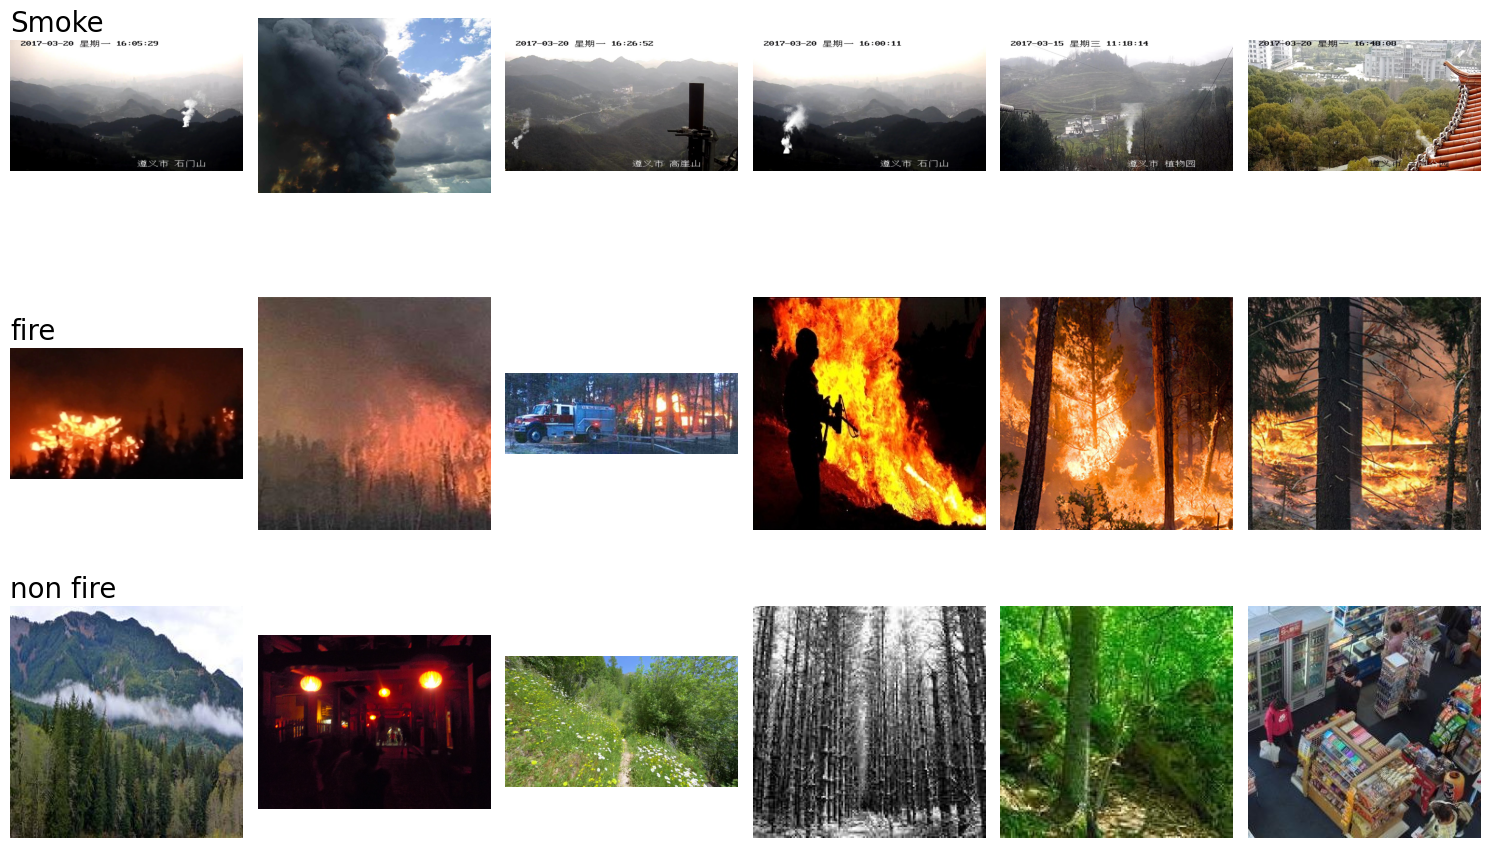

In [3]:
import matplotlib.pyplot as plt
import cv2
import random

os.makedirs('../reports/figures', exist_ok=True)

def show_samples(directory, classes, n_samples=6):
    fig, axes = plt.subplots(len(classes), n_samples, figsize=(15, 10))
    
    for i, label in enumerate(classes):
        label_path = os.path.join(directory, label)

        sample_files = random.sample(os.listdir(label_path), n_samples)
        
        for j, file_name in enumerate(sample_files):
            img_path = os.path.join(label_path, file_name)

            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(label, fontsize=20, loc='left')

    plt.tight_layout()

    plt.savefig('../reports/figures/01_sample_grid.png')
    plt.show()


classes = ['Smoke', 'fire', 'non fire']
show_samples(train_dir, classes)

# 02. Full inspection and balance ratio calculation

Scanning non fire: 100%|██████████| 10800/10800 [00:22<00:00, 482.77it/s]



--- [Final Dataset Report] ---
      class  count  percentage
0     Smoke  10800       33.33
1      fire  10800       33.33
2  non fire  10800       33.33

Total Images Scanned: 32400
Total Corrupt Files Found: 0


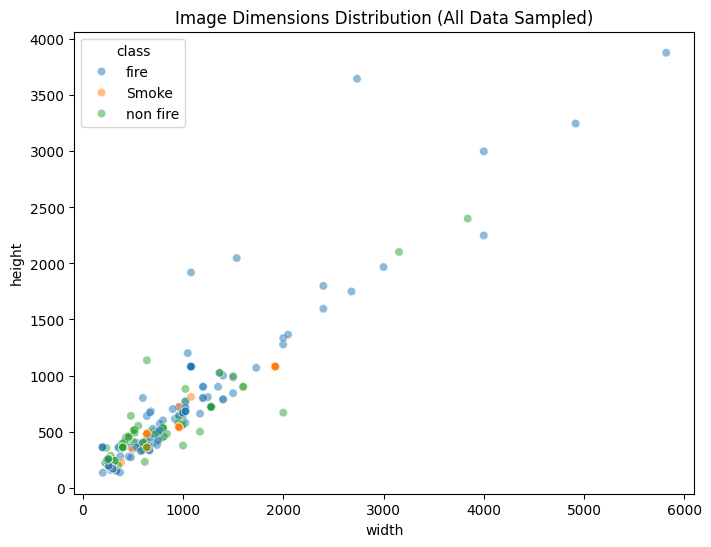


--- [Dimension Statistics per Class] ---
            width                                                          \
            count         mean         std    min     25%     50%     75%   
class                                                                       
Smoke     10800.0  1617.343704  585.351208  117.0  1920.0  1920.0  1920.0   
fire      10800.0   657.125648  698.549600  148.0   250.0   275.0  1000.0   
non fire  10800.0   545.159907  531.063900  175.0   256.0   256.0   640.0   

                   height                                                 \
             max    count        mean         std    min     25%     50%   
class                                                                      
Smoke     5273.0  10800.0  930.373333  302.050875  102.0  1080.0  1080.0   
fire      7952.0  10800.0  488.840556  483.474953  100.0   250.0   256.0   
non fire  9498.0  10800.0  400.759167  307.250680  165.0   250.0   256.0   

                          
           

In [4]:
from PIL import Image
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def perform_full_eda(directory, classes):
    all_data = []
    corrupt_files = []
    
    # 1. full inspection
    for label in classes:
        label_path = os.path.join(directory, label)
        files = os.listdir(label_path)
        
        for f in tqdm(files, desc=f"Scanning {label}"):
            file_path = os.path.join(label_path, f)
            try:
                with Image.open(file_path) as img:
                    # collect image size
                    w, h = img.size
                    all_data.append({
                        'class': label,
                        'width': w,
                        'height': h
                    })
                    # check file integrity
                    img.verify() 
            except Exception as e:
                # corrupted file log
                corrupt_files.append(file_path)
    
    # 2. Dataframe
    df = pd.DataFrame(all_data)
    
    # 3. Calculate the number of samples per class and their percentage distribution
    summary_stats = df['class'].value_counts().reset_index()
    summary_stats.columns = ['class', 'count']
    summary_stats['percentage'] = (summary_stats['count'] / len(df) * 100).round(2)
    
    print("\n--- [Final Dataset Report] ---")
    print(summary_stats)
    print(f"\nTotal Images Scanned: {len(df)}")
    print(f"Total Corrupt Files Found: {len(corrupt_files)}")
    if corrupt_files:
        print("List of corrupt files:", corrupt_files)

    # 4. Visualization of image size distribution
    # sampling 1000 images
    plt.figure(figsize=(8, 6))
    sample_df = df.sample(min(1000, len(df)), random_state=42)
    sns.scatterplot(data=sample_df, x='width', y='height', hue='class', alpha=0.5)
    plt.title('Image Dimensions Distribution (All Data Sampled)')
    
    plt.savefig('../reports/figures/02_dimensions.png')
    plt.show()

    # 5. Summary of image size statistics
    print("\n--- [Dimension Statistics per Class] ---")
    print(df.groupby('class').describe())
    
    return df, summary_stats

# execution
df_all, final_summary = perform_full_eda(train_dir, classes)

# 03. Brighteness and RGB

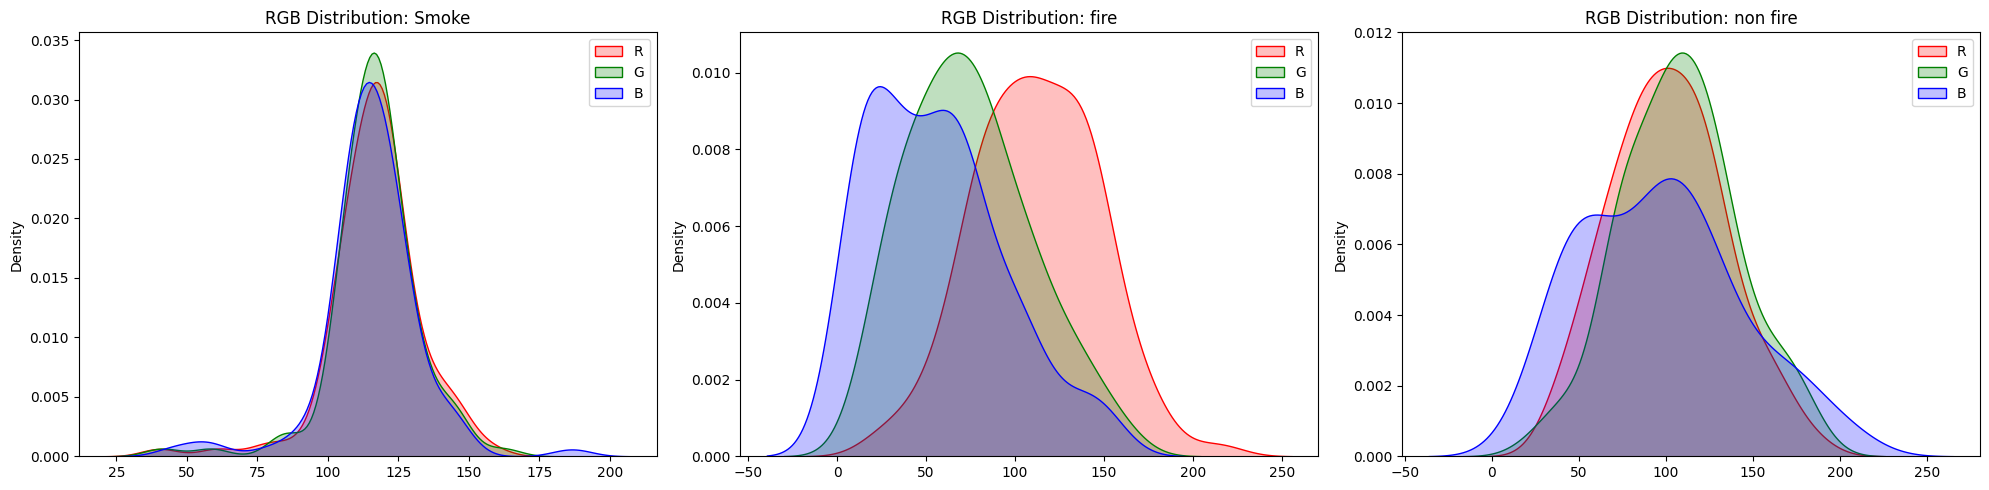

In [5]:
import numpy as np

def plot_rgb_distribution(directory, classes, n_samples=100):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    colors = ('r', 'g', 'b')
    
    for i, label in enumerate(classes):
        label_path = os.path.join(directory, label)
        sample_files = random.sample(os.listdir(label_path), n_samples)
    
        ch_means = {0: [], 1: [], 2: []}
        
        for file_name in sample_files:
            img = cv2.imread(os.path.join(label_path, file_name))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            for j in range(3): # calculation average by R, G, and B channels
                ch_means[j].append(np.mean(img[:, :, j]))
        
        # drawing histogram
        for j, col in enumerate(colors):
            sns.kdeplot(ch_means[j], ax=axes[i], color=col, fill=True, label=col.upper())
        
        axes[i].set_title(f"RGB Distribution: {label}")
        axes[i].legend()

    plt.tight_layout()
    plt.savefig('../reports/figures/03_rgb_distribution.png')
    plt.show()

# execution
plot_rgb_distribution(train_dir, classes)

# 04-05. Brightness and ambiguous

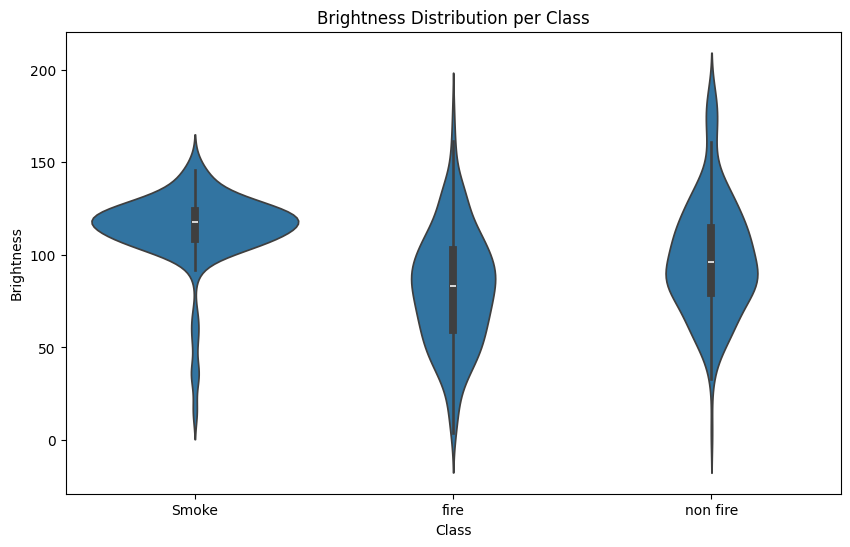

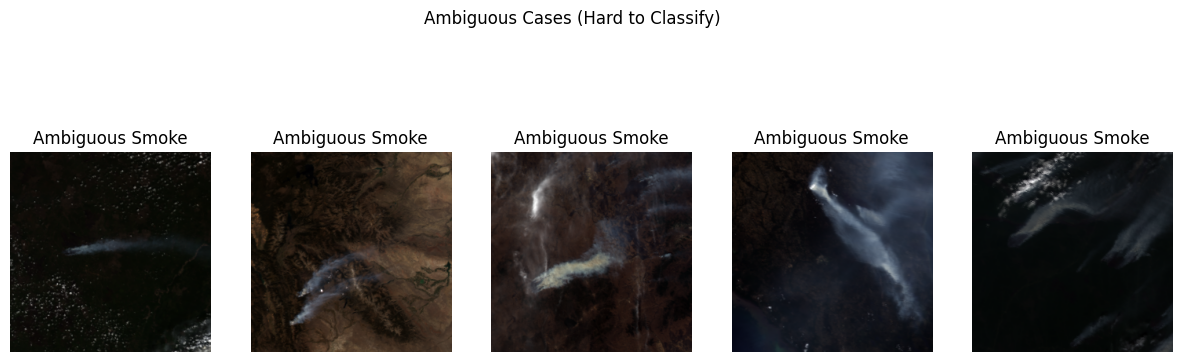

In [6]:
def plot_brightness_and_ambiguous(directory, classes):
    brightness_data = []
    ambiguous_samples = []

    for label in classes:
        label_path = os.path.join(directory, label)
        files = random.sample(os.listdir(label_path), 200) # sampling 200 images
        
        for f in files:
            img = cv2.imread(os.path.join(label_path, f))
            if img is None: continue
            
            # Brightness calculation (average value after grayscale conversion)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            avg_brightness = np.mean(gray)
            brightness_data.append({'Class': label, 'Brightness': avg_brightness})
            
            # Save cases of Smoke where brightness is too low (dark smoke)
            # Cases of Non-fire where brightness is too high (foggy forest) as 'Ambiguous cases'
            if label == 'Smoke' and (avg_brightness < 50 or avg_brightness > 200):
                ambiguous_samples.append((img, label, f))

    # 1. Visualization of brightness distribution
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=pd.DataFrame(brightness_data), x='Class', y='Brightness')
    plt.title('Brightness Distribution per Class')
    plt.savefig('../reports/figures/04_brightness_distribution.png')
    plt.show()

    # 2. Output ambiguous cases (max. 5)
    if ambiguous_samples:
        plt.figure(figsize=(15, 5))
        for i, (img, label, name) in enumerate(ambiguous_samples[:5]):
            plt.subplot(1, 5, i+1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f"Ambiguous {label}")
            plt.axis('off')
        plt.suptitle("Ambiguous Cases (Hard to Classify)")
        plt.savefig('../reports/figures/05_ambiguous_cases.png')
        plt.show()

plot_brightness_and_ambiguous(train_dir, classes)

---
---
---
# Data Cleaning

In [7]:
import os
import tensorflow as tf
from tqdm import tqdm

def tf_native_cleanup(directory):
    """
    Identifies and deletes files that TensorFlow's C++ decoder cannot read.
    This solves the 'Unknown image file format' error for good.
    """
    removed_count = 0
    
    # Get all file paths
    all_files = []
    for root, _, files in os.walk(directory):
        for file in files:
            if not file.startswith('.'): # Skip system hidden files
                all_files.append(os.path.join(root, file))
    
    print(f"Verifying {len(all_files)} files with TensorFlow decoder in {directory}...")
    
    for file_path in tqdm(all_files):
        try:
            # 1. Read the raw file
            img_raw = tf.io.read_file(file_path)
            # 2. Try to decode it using TF's internal engine
            # This is the exact part where the previous code crashed
            _ = tf.io.decode_image(img_raw, channels=3, expand_animations=False)
        except Exception:
            # If TF fails to decode, delete the file physically
            print(f"\n[DELETING] Incompatible file found: {file_path}")
            os.remove(file_path)
            removed_count += 1
            
    print(f"\nTF Native Cleanup Finished: {directory}")
    print(f"- Files actually deleted by TF criteria: {removed_count}")

# Execute the final cleanup on both directories
tf_native_cleanup(train_dir)
tf_native_cleanup(test_dir)

ModuleNotFoundError: No module named 'tensorflow'